In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import pickle

import sys
import os
sys.path.append("/home/gc/workspace/drugPert/XPert")

os.chdir("/home/gc/workspace/drugPert/XPert")
os.getcwd()


%load_ext autoreload
%autoreload 2

# 获得相应的数据

In [2]:
adata = sc.read_h5ad('processed_data/l1000_sdst_78453_5.h5ad')
tissue_idx_dict = np.load('processed_data/l1000_tissue2idx_21.npy', allow_pickle=True).item()
idx2tissue = {v:k for k,v in tissue_idx_dict.items()}
adata.obs['tissue'] = adata.obs.tissue_idx.map(idx2tissue)
adata

AnnData object with n_obs × n_vars = 78453 × 978
    obs: 'sample_id', 'bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_time', 'pert_itime', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'det_plate', 'det_well', 'rna_plate', 'rna_well', 'count_mean', 'count_cv', 'qc_f_logp', 'qc_iqr', 'qc_slope', 'pert_id', 'pert_type', 'cell_iname', 'qc_pass', 'dyn_range', 'inv_level_10', 'build_name', 'failure_mode', 'project_code', 'cmap_name', 'n_replicates', 'pert_idx', 'cell_idx', 'tissue_idx', 'cell_pert_dose_time', 'split_1', 'split_2', 'split_3', 'split_4', 'split_5', 'split_cold_drug_1', 'split_cold_drug_2', 'split_cold_drug_3', 'split_cold_drug_4', 'split_cold_drug_5', 'split_cold_cell_1', 'split_cold_cell_2', 'split_cold_cell_3', 'split_cold_cell_4', 'split_cold_cell_5', 'split_cold_cell_1_one_shot', 'split_cold_cell_1_0.1_shot', 'split_cold_cell_1_0.3_shot', 'split_cold_cell_1_0.5_shot', 'split_cold_cell_1_0.8_shot', 'split_cold_cell_2_one_shot', 'split_

In [3]:
drug_info = pd.read_csv('processed_data/l1000_sdst_drugs_info_8432.csv', index_col=0)
select_moa = "EGFR inhibitor"
EGFR_drug_info = drug_info[drug_info.moa==select_moa]
EGFR_drug_id_ls = EGFR_drug_info.index.unique()
adata_filter = adata[adata.obs.pert_id.isin(EGFR_drug_id_ls)]
adata_filter.obs.tissue.value_counts()

tissue
unknown                               180
lung                                  173
breast                                121
prostate                               73
haematopoietic_and_lymphoid_tissue     63
skin                                   45
kidney                                 45
soft_tissue                            36
large_intestine                        32
central_nervous_system                 29
ovary                                  29
liver                                  24
endometrium                            20
cervix                                 16
pancreas                               15
urinary_tract                          10
stomach                                10
bone                                    9
placenta                                6
upper_aerodigestive_tract               4
autonomic_ganglia                       2
Name: count, dtype: int64

In [ ]:
tissue = 'all'
select_adata = adata[(adata.obs.tissue != "unknown") & (adata.obs.pert_id.isin(EGFR_drug_id_ls))]

select_adata.obs.cmap_name.value_counts()

cmap_name
afatinib            97
gefitinib           85
erlotinib           82
vandetanib          66
WZ-4002             35
canertinib          31
dovitinib           26
KIN001-055          25
CP-724714           24
neratinib           21
BIBX-1382           20
AG-490              19
dacomitinib         19
AST-1306            17
CGP-53353           14
pelitinib           13
RG-14620            12
tyrphostin-47       12
GW-583340           12
BIBU-1361           11
tyrphostin          11
TAK-285             11
CGP-52411           10
rociletinib         10
BMS-599626           9
lavendustin-c        9
AG-494               8
erbstatin-analog     8
bis-tyrphostin       8
PD-158780            8
WZ-3146              8
ARRY-334543          7
butein               6
LFM-A12              4
lapatinib            4
Name: count, dtype: int64

In [5]:
select_adata = select_adata[select_adata.obs.cmap_name.isin(['gefitinib', 'erlotinib'])]
select_adata.n_obs

167

In [6]:
dataset_name = f"l1000_sdst_{tissue}_{select_moa.split(' ')[0]}"
print(f"saveing to processed_data_infer/{dataset_name}.h5ad")
select_adata.write_h5ad(f'processed_data_infer/{dataset_name}.h5ad')

saveing to processed_data_infer/l1000_sdst_all_EGFR.h5ad


/home/gc/.conda/envs/openbiomed/lib/python3.9/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


# 用指定的数据得到attn profile

In [ ]:
from datasets.MyDataset import MyDataset
from models.model_XPert import XPertNet
from metrics import get_metrics_infer

import torch
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
import yaml
import logging
import time
from argparse import Namespace

In [ ]:
file_name = f"EGFRi_{tissue.split('_')[0]}"
expt_folder = f"experiment_snn_infer/plot_attn_molecule/{file_name}/" 
if not os.path.exists(expt_folder):
    os.makedirs(expt_folder)
timestamp = time.strftime('%Y%m%d_%H%M%S', time.localtime())

config_path = "configs/config_snn.yaml"
with open(f'{config_path}', 'r') as f:
    config = yaml.safe_load(f)
print(config)


args = Namespace(
    mode="infer",
    nfold="split_5",
    drug_feat="unimol",
    device="cuda:1",
    model="XPert_SNN",
    config="config",
    seed=0,
    dataset=dataset_name,
    pretrained_mode="global",
    include_cell_idx=True,
    wo_HG=False,
    wo_atom=False,
    wo_atom_HG=False,
    wo_unimol=False,
    wo_ppi=False,
    use_gene_pos_emed=False,
    drug_pos_emb_type="learnable",
    wo_cell_loss=False,
    wo_pcc_loss=False,
    use_gradscaler=False,
    lr_scheduler=True,
    resume_from=None,
    saved_model_path="experiment_snn/sdst_five_seeds",
    saved_model=None,
    pretrained_model=None,
    output_profile=False,
    output_attention=True,
    output_cls_embed=False,
    weighted_loss=False,
    kl_loss=False,
)

print(args)

{'model': {'XPert': None, 'ATTN': {'n_heads': 8, 'attention_probs_dropout_prob': 0.1, 'hidden_dropout_prob': 0.1, 'cell_input_hidden_dropout_prob': 0.1, 'drug_input_hidden_dropout_prob': 0.1, 'topk_cell': 128, 'topk_drug': 32, 'sparse_flag': False, 'hidden_size': 256, 'trt_structure': 'CA+SA+SA+CA', 'ctl_structure': 'SA+SA+SA+SA', 'ppi_gene_vector_path': 'processed_data/PPI_gene_vector_128d.npy'}, 'HG': {'node_input_dim': 512, 'conv_layers': 2, 'hg_path': 'processed_data_HG_L1000/', 'drug_hg_pretrained_embed_path': 'processed_data_HG_L1000/HG_drug_embeddings_20241109_120917.npy', 'specific_pretrained_embed_path': None}}, 'dataset': {'n_bins': 128, 'gene_num': 978, 'atom_num': 24, 'max_atom_size': 122, 'max_value': 15.002, 'min_value': 0.0, 'l1000': {'num_pert_dose': 10, 'num_pert_time': 3, 'num_cell_id': 240, 'num_tissue_id': 21}, 'panacea': {'num_pert_dose': 10, 'num_pert_time': 3, 'num_cell_id': 240, 'num_tissue_id': 21}, 'cdsdb': {'num_pert_dose': 11, 'num_pert_time': 8, 'num_cell_i

In [9]:
# define logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG) # .DEBUG/INFO/WARNING/ERROR/CRITICAL
fh = logging.FileHandler(expt_folder+f'/{file_name}_{timestamp}.log')
fh.setLevel(logging.DEBUG)
logger.addHandler(fh)
ch = logging.StreamHandler()
ch.setLevel(logging.DEBUG)
logger.addHandler(ch)

In [10]:
def load_infer_dataloader(args,config,logger):

    batch_size = 1
    data = sc.read_h5ad(f'processed_data_infer/{args.dataset}.h5ad')
    drug_feat = np.load(config['dataset']['drug_unimol_path'], allow_pickle=True)

    test_data = data

    print(f'Test data:{test_data.n_obs}')

    if 'l1000' not in args.dataset:
        max_value = round(data.X.max(),1)
        min_value = round(data.X.min(),1)
        print(f'For dataset {args.dataset}, max_value:{max_value}, min_value:{min_value}')
    else:
        max_value, min_value = None, None

    print("Starting load infer data...")
    test_dataset = MyDataset(test_data, drug_feat, args=args, config=config, logger=logger, max_value=max_value, min_value=min_value)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=10, drop_last=False)

    print(f'Test dataloader:{len(test_dataloader)}')
    
    return test_dataloader


In [ ]:
output_attention_branch = ["trt"]
output_attention_layers = ["CA_0", "CA_3"]
output_attention_mode = "mean_heads"  # .mean(axis=0).mean(axis=0)

def infer(model, dataloader, args, config, flag=True, output_profile=False, scaler=None):
    model.eval()  
    trt_raw_data_ls = []
    output2_ls = []
    ctl_raw_data_ls = []
    pert_id_ls = []
    cell_id_ls = []
    pert_dose_ls = []
    pert_time_ls = []
    trt_attention_dict_ls= {}
    ctl_attention_dict_ls= {}
    cls_embed_ls = []


    with torch.no_grad():  

        for data in dataloader:
            trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned, drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx, pert_id, cell_id, pert_dose, pert_time = data
            # feat_data = trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned,drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx  

            if scaler:
                with autocast():
                    trt_output, ctl_output, output_deg, _, _, attention_dict, _, _, cls_embed= model((trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned,drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx))
            else:
                trt_output, ctl_output, output_deg, _, _, attention_dict, _, _, cls_embed = model((trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned,drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx))                     

            if flag:
                trt_raw_data_ls.append(trt_raw_data)
                output2_ls.append(output_deg.cpu()+ctl_raw_data)
                ctl_raw_data_ls.append(ctl_raw_data)
                if args.output_attention:
                    trt_attention_dict, ctl_attention_dict = attention_dict
                    if "trt" in output_attention_branch:
                        for key, value in trt_attention_dict.items():
                            # print(key, value.shape)
                            if key in output_attention_layers:
                                if key not in trt_attention_dict_ls:
                                    trt_attention_dict_ls[key] = []
                                trt_attention_dict_ls[key].append(value.mean(axis=1).mean(axis=1) if output_attention_mode=="mean_heads" else value)
                    if "ctl" in output_attention_branch:
                        for key, value in ctl_attention_dict.items():
                            if key in output_attention_layers:
                                if key not in ctl_attention_dict_ls:
                                    ctl_attention_dict_ls[key] = []
                                ctl_attention_dict_ls[key].append(value.mean(axis=1).mean(axis=1) if output_attention_mode=="mean_heads" else value)

                if args.output_cls_embed:
                    cls_embed_ls.append(cls_embed)

                pert_id = list(drug_idx)
                cell_id = list(cell_id)
                pert_dose = list(pert_dose)
                pert_time = list(pert_time)

                pert_id_ls.extend(pert_id)
                cell_id_ls.extend(cell_id)
                pert_dose_ls.extend(pert_dose)
                pert_time_ls.extend(pert_time)


        if flag:
            y_true = torch.cat(trt_raw_data_ls, dim=0).cpu().detach().numpy()
            y_pred = torch.cat(output2_ls, dim=0).cpu().detach().numpy()
            ctl_true = torch.cat(ctl_raw_data_ls, dim=0).cpu().detach().numpy()
            metrics, metrics_all_ls = get_metrics_infer(y_true, y_pred, ctl_true)

            metrics_all_ls['pert_id'] = np.array(pert_id_ls)
            metrics_all_ls['cell_id'] = np.array(cell_id_ls)
            metrics_all_ls['pert_dose'] = np.array(pert_dose_ls)
            metrics_all_ls['pert_time'] = np.array(pert_time_ls)
        else:
            metrics = None
            metrics_all_ls = None

        
        
        # output attention
        all_attention_dict = None
        if args.output_attention:
            all_attention_dict = {}
            all_trt_attention_dict = {}
            all_ctl_attention_dict = {}
            if trt_attention_dict_ls != {}:
                for key, value in trt_attention_dict_ls.items():
                    all_trt_attention_dict[key] = torch.cat(value, dim=0).cpu().detach().numpy()
                all_attention_dict['trt'] = all_trt_attention_dict
            if ctl_attention_dict_ls != {}:
                for key, value in ctl_attention_dict_ls.items():
                    all_ctl_attention_dict[key] = torch.cat(value, dim=0).cpu().detach().numpy()
                all_attention_dict['ctl'] = all_ctl_attention_dict 

        # output cls_embed
        all_cls_embed = None
        if args.output_cls_embed:
            all_cls_embed = torch.cat(cls_embed_ls, dim=0).cpu().detach().numpy()

    
        if output_profile:
            output_pred_profile = {}
            output_pred_profile['y_true'] = y_true
            output_pred_profile['y_pred'] = y_pred
            output_pred_profile['ctl_true'] = ctl_true
            output_pred_profile['deg_true'] = y_true-ctl_true
            output_pred_profile['deg_pred'] = y_pred-ctl_true
        else:
            output_pred_profile = None

    return metrics, metrics_all_ls, output_pred_profile, all_attention_dict, all_cls_embed

In [ ]:
test_dataloader = load_infer_dataloader(args,config, logger)
device = args.device
fold = args.nfold
model = XPertNet(args, config, device, logger)
model.to(device)

# load model
all_attention_dict = {}
for seed in [0,1,2,3,4]:
    print(f'=================== seed {seed} ===================')
    saved_model = f"{args.saved_model_path}/xpert_seed{seed}/{fold}_fold_early_stop.pth"
    print(f'Loading model from {saved_model}')
    checkpoint = torch.load(saved_model)
    model_dict = model.state_dict()
    pretrained_dict = {k:v for k,v in checkpoint['model_state_dict'].items() if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)


    start_time = time.time()
    logger.info('Start testing  ... ')
    logger.info('Testing on test dataset:')
    test_metrics, test_metrics_all_ls, test_output_pred_profile, test_all_attention_dict, all_cls_embed = infer(model, test_dataloader, args, config, flag=True, output_profile=args.output_profile, scaler=args.use_gradscaler)

    logger.info(f"{int(time.time() - start_time)/60:.2f}mins")
    logger.info('Test Metrics:')
    logger.info(test_metrics)

    all_attention_dict[f"seed{seed}"] = test_all_attention_dict

pert_dose_idx:
pert_dose_idx
8    167
Name: count, dtype: int64
binning process... n_bins:128


Test data:167
Starting load infer data...


100%|██████████| 167/167 [00:00<00:00, 460.73it/s]
For cell embedding: using ppi_gene_vector + exp embedding


Test dataloader:167


Using sparse attn: False
Using sparse attn: False


...

Start testing  ... 
Testing on test dataset:
0.12mins
Test Metrics:
{'MSE': 0.215, 'RMSE': 0.464, 'MAE': 0.301, 'Pearson': 0.979, 'Spearman': 0.977, 'Precision@10 Positive': 0.993, 'Precision@10 Negative': 0.983, 'Precision@20 Positive': 0.99, 'Precision@20 Negative': 0.984, 'Precision@50 Positive': 0.985, 'Precision@50 Negative': 0.969, 'Precision@100 Positive': 0.895, 'Precision@100 Negative': 0.882, 'MSE_deg': 0.215, 'RMSE_deg': 0.464, 'MAE_deg': 0.301, 'Pearson_deg': 0.741, 'Spearman_deg': 0.68, 'Precision@10 Positive_deg': 0.917, 'Precision@10 Negative_deg': 0.892, 'Precision@20 Positive_deg': 0.856, 'Precision@20 Negative_deg': 0.831, 'Precision@50 Positive_deg': 0.714, 'Precision@50 Negative_deg': 0.693, 'Precision@100 Positive_deg': 0.548, 'Precision@100 Negative_deg': 0.541}


=================== seed 3 ===================
Loading model from experiment_snn/sdst_five_seeds/xpert_seed3/split_5_fold_early_stop.pth


Start testing  ... 
Testing on test dataset:
0.12mins
Test Metrics:
{'MSE': 0.216, 'RMSE': 0.464, 'MAE': 0.301, 'Pearson': 0.979, 'Spearman': 0.977, 'Precision@10 Positive': 0.99, 'Precision@10 Negative': 0.982, 'Precision@20 Positive': 0.99, 'Precision@20 Negative': 0.98, 'Precision@50 Positive': 0.985, 'Precision@50 Negative': 0.969, 'Precision@100 Positive': 0.895, 'Precision@100 Negative': 0.881, 'MSE_deg': 0.216, 'RMSE_deg': 0.464, 'MAE_deg': 0.301, 'Pearson_deg': 0.741, 'Spearman_deg': 0.681, 'Precision@10 Positive_deg': 0.91, 'Precision@10 Negative_deg': 0.889, 'Precision@20 Positive_deg': 0.858, 'Precision@20 Negative_deg': 0.831, 'Precision@50 Positive_deg': 0.714, 'Precision@50 Negative_deg': 0.691, 'Precision@100 Positive_deg': 0.544, 'Precision@100 Negative_deg': 0.543}


=================== seed 4 ===================
Loading model from experiment_snn/sdst_five_seeds/xpert_seed4/split_5_fold_early_stop.pth


Start testing  ... 
Testing on test dataset:
0.12mins
Test Metrics:
{'MSE': 0.228, 'RMSE': 0.477, 'MAE': 0.311, 'Pearson': 0.978, 'Spearman': 0.976, 'Precision@10 Positive': 0.992, 'Precision@10 Negative': 0.979, 'Precision@20 Positive': 0.99, 'Precision@20 Negative': 0.979, 'Precision@50 Positive': 0.983, 'Precision@50 Negative': 0.967, 'Precision@100 Positive': 0.888, 'Precision@100 Negative': 0.877, 'MSE_deg': 0.228, 'RMSE_deg': 0.477, 'MAE_deg': 0.311, 'Pearson_deg': 0.722, 'Spearman_deg': 0.659, 'Precision@10 Positive_deg': 0.898, 'Precision@10 Negative_deg': 0.878, 'Precision@20 Positive_deg': 0.849, 'Precision@20 Negative_deg': 0.809, 'Precision@50 Positive_deg': 0.695, 'Precision@50 Negative_deg': 0.672, 'Precision@100 Positive_deg': 0.527, 'Precision@100 Negative_deg': 0.527}


In [16]:
test_all_attention_dict.keys(), test_all_attention_dict["trt"].keys(), test_all_attention_dict["trt"]["CA_0"].shape

(dict_keys(['trt']), dict_keys(['CA_0', 'CA_3']), (167, 122))

In [17]:
all_attention_dict.keys()

dict_keys(['seed0', 'seed1', 'seed2', 'seed3', 'seed4'])

# 定义分子可视化函数

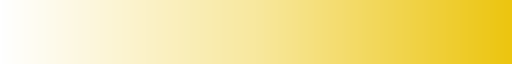

In [ ]:
import matplotlib.colors as mcolors

colorlist = ['#FFFFFF',  '#F8E89E', '#ECC50F']
# colorlist = ["#B691BE", '#D8BAE3',  '#FFFFFF',  '#D2E0FA', '#3074E4']

# colorlist = ["white", "#D2E3C6","#548235"]

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap", colorlist
)

custom_cmap

In [ ]:
from experiment_snn_infer.plot_attn_molecule.molecule_vis import visualize_molecule_attention, plot_attention_heatmap, plot_attention_scatter
from rdkit import Chem

drug_smi = np.load('processed_data/all_drugs_idx2smi_8981.npy', allow_pickle=True).item()


def drawAttn(drug_name, all_attn_dict, seed, layer, start_idx=4, save_path=None, norm=True, figsize=(18,6), radius=30):
    # attn: an unique attention matrix, shape: [seq_len, seq_len]
    # start_idx: if sdst, start_idx=2; if mdmt, start_idx=4; 

    idx_ls = np.where(select_adata.obs.cmap_name == drug_name)[0]
    idx = idx_ls[0]
    drug_idx = select_adata.obs.iloc[idx, :]['pert_idx']
    smi = drug_smi[drug_idx]

    mol = Chem.MolFromSmiles(smi)
    num_atom = mol.GetNumAtoms()
    
    atom_attn_dict = {}
    atom_attn_mean_dict = {}
    for key in all_attn_dict.keys():
        attn_dict = all_attn_dict[key]["trt"]
        if '+' not in layer:
            attn = np.array([attn_dict[layer][idx] for idx in idx_ls])
            atom_attn = attn[:, start_idx:start_idx+num_atom]
            atom_attn_mean = atom_attn.mean(axis=0)
        else:
            attn_1 = np.array([attn_dict["CA_0"][idx] for idx in idx_ls])
            atom_attn_1 = attn_1[:, start_idx:start_idx+num_atom]
            atom_attn_1_mean = atom_attn_1.mean(axis=0)

            attn_2 = np.array([attn_dict["CA_3"][idx] for idx in idx_ls])
            atom_attn_2 = attn_2[:, start_idx:start_idx+num_atom]
            atom_attn_2_mean = atom_attn_2.mean(axis=0)

            atom_attn = (atom_attn_1 + atom_attn_2) / 2
            atom_attn_mean = (atom_attn_1_mean + atom_attn_2_mean) / 2
        
        atom_attn_dict[key] = atom_attn
        atom_attn_mean_dict[key] = atom_attn_mean
    
    # fig, axes = plt.subplots(3, 1, figsize=figsize, gridspec_kw={'height_ratios': [1.2, 1, 1]} )
    fig, axes = plt.subplots(1, 3, figsize=figsize, gridspec_kw={'width_ratios': [1, 1, 1]} )
    axes = axes.flatten()

    attention_mean_arr = np.array([atom_attn_mean_dict[f"seed{i}"] for i in range(5)])

    if seed == "mean":
        atom_attn_mean_seed = attention_mean_arr.mean(axis=0)
        atom_attn_heatmap_for_one_seed = atom_attn_dict[f"seed0"]
    else:
        atom_attn_mean_seed = atom_attn_mean_dict[f"seed{seed}"]
        atom_attn_heatmap_for_one_seed = atom_attn_dict[f"seed{seed}"]

    # plot molecule
    visualize_molecule_attention(smi, atom_attn_mean_seed, norm=norm, radius=radius, save_path=None, color_factor=0.5, ax=axes[0], cmap=custom_cmap)

    # plot heatmap across samples
    plot_attention_heatmap(atom_attn_heatmap_for_one_seed, annot=False, save_path=None, ax=axes[1], cmap=custom_cmap)

    # plot scatter across seeds
    plot_attention_scatter(attention_mean_arr, cmap='Paired', ax=axes[2])

    fig.suptitle(f'Attention Visualization for {drug_name.capitalize() if not drug_name[0].isupper() else drug_name}', fontsize=24, y=1.1)
    # plt.tight_layout()
    # Set spacing between subplots
    plt.subplots_adjust(wspace=0.2)

    if save_path:
        fig.savefig(save_path, format="svg", dpi=300, bbox_inches='tight')
        print(f"Saving to: {save_path}")
    
    # Output atom_attn_dict as dataframe
    attn_dfs = []
    for key in atom_attn_dict.keys():
        attn_df = pd.DataFrame(atom_attn_dict[key].T) # [num_atom, num_sample]
        attn_df.columns = [f"{key}"] * attn_df.shape[1]
        attn_dfs.append(attn_df)
    attn_df = pd.concat(attn_dfs, axis=1)

    # Output atom_attn_mean_dict as dataframe
    for key in atom_attn_mean_dict.keys():
        attn_df[f"{key}_mean"] = atom_attn_mean_dict[key]
        
    # Output atom types and mean attention scores
    atom_ls = [atom.GetSymbol() for atom in mol.GetAtoms()]
    print(atom_ls)
    attn_df.index = atom_ls
    attn_df["five_seeds_mean_attenion"] = atom_attn_mean_seed

    
    plt.show()

    return fig, attn_df

# 分子可视化

In [21]:
select_adata.obs.cmap_name.value_counts()

cmap_name
gefitinib    85
erlotinib    82
Name: count, dtype: int64

['C', 'O', 'C', 'C', 'C', 'N', 'C', 'N', 'C', 'N', 'C', 'C', 'C', 'C', 'F', 'C', 'Cl', 'C', 'C', 'C', 'C', 'O', 'C', 'C', 'C', 'N', 'C', 'C', 'O', 'C', 'C']


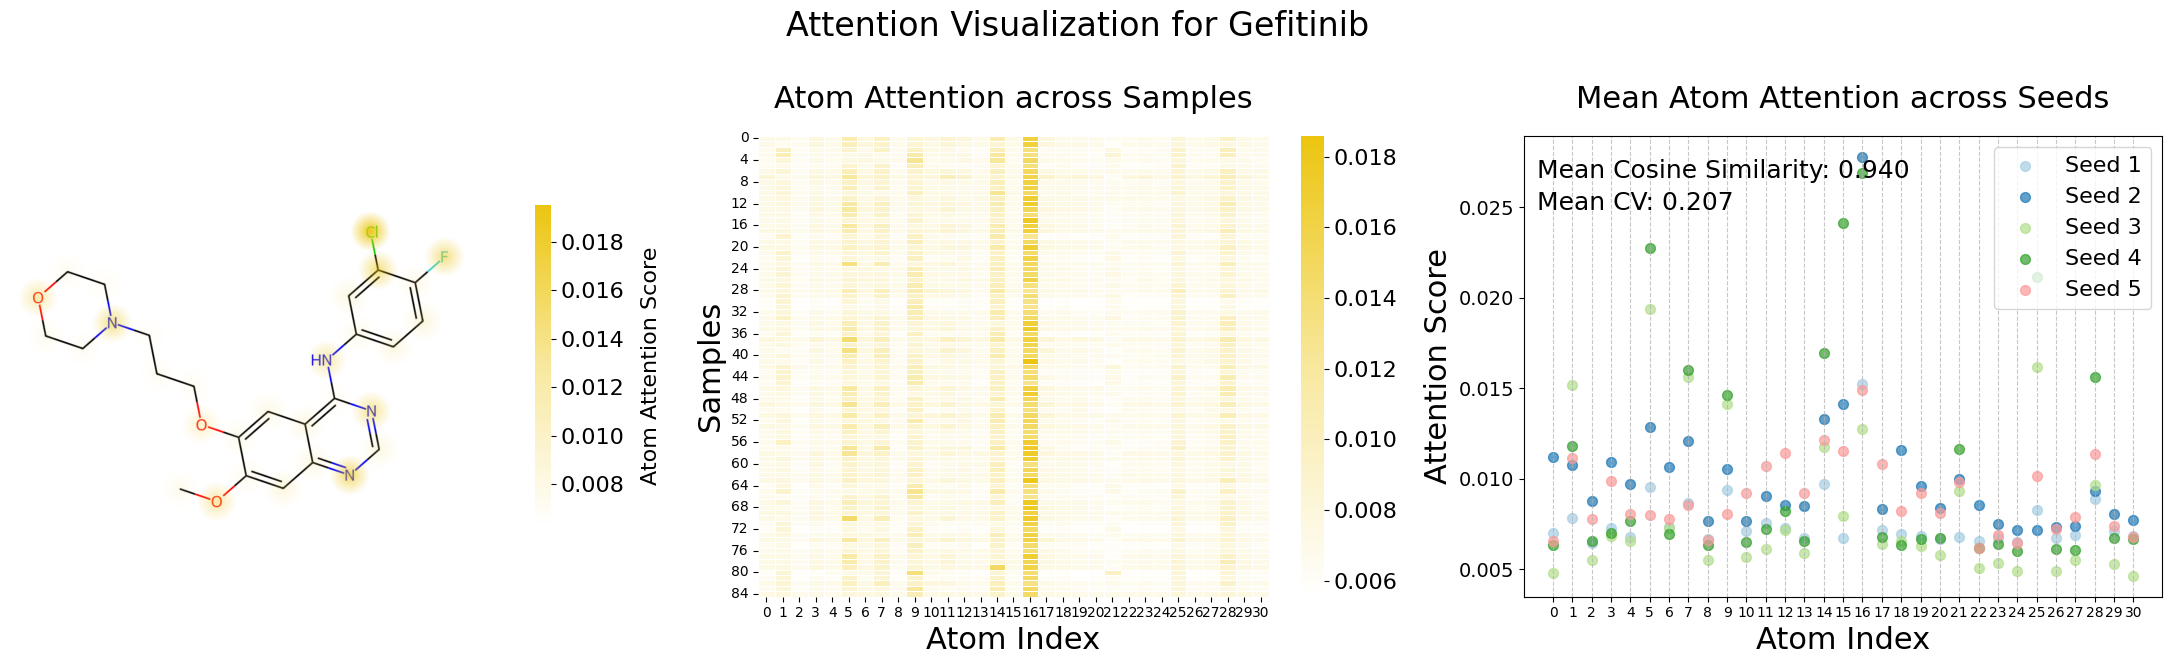

['C', 'C', 'C', 'C', 'C', 'C', 'C', 'N', 'C', 'N', 'C', 'N', 'C', 'C', 'C', 'O', 'C', 'C', 'O', 'C', 'C', 'O', 'C', 'C', 'O', 'C', 'C', 'C', 'C']


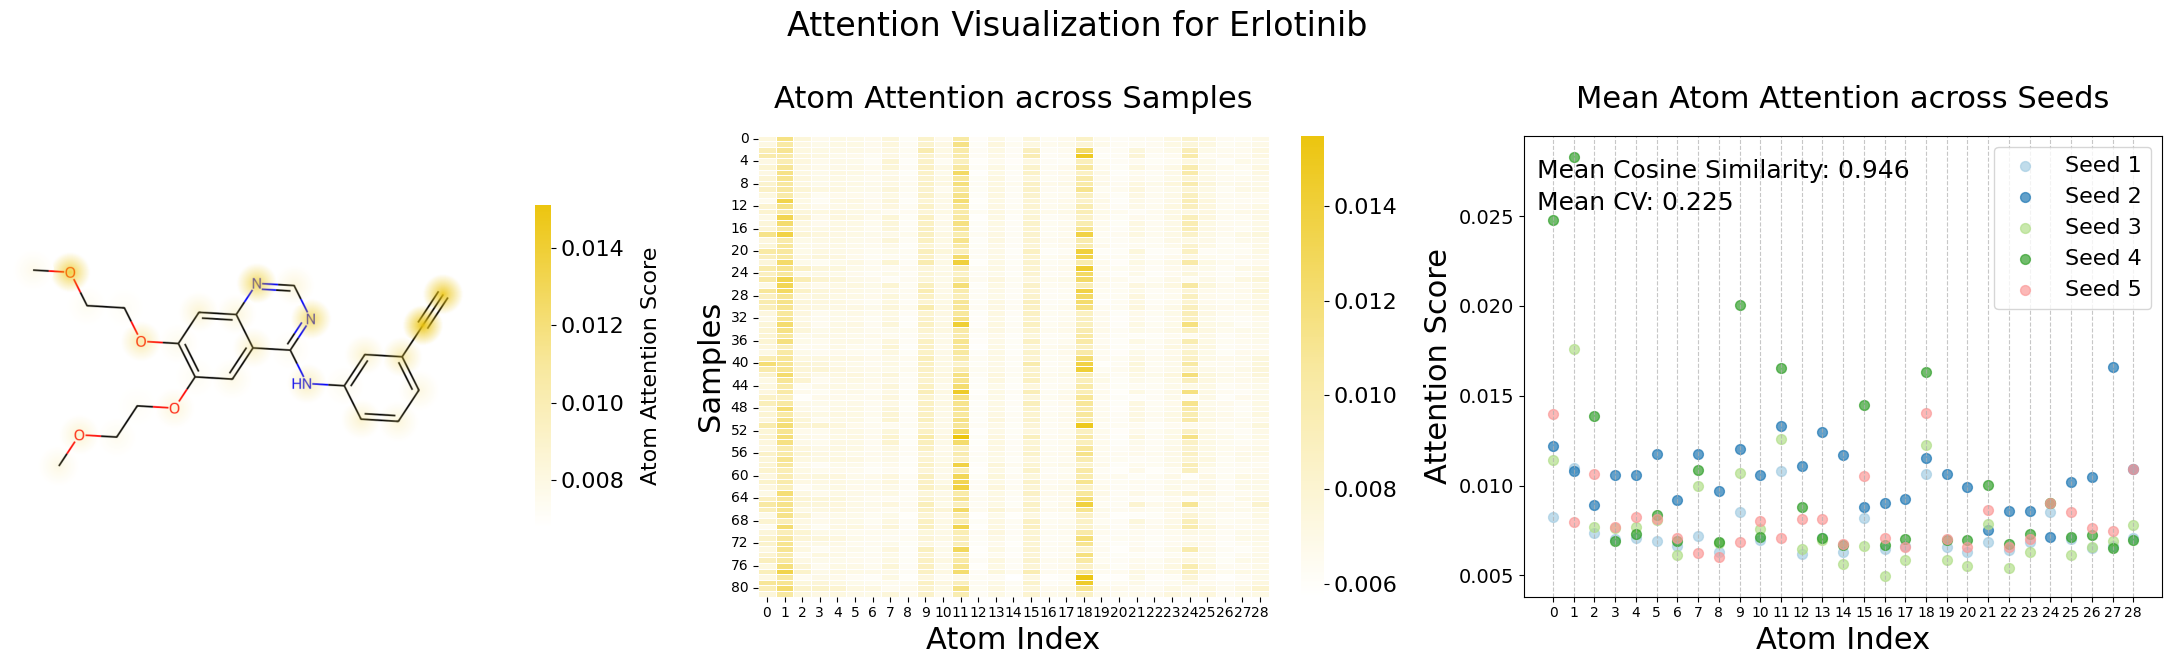

In [ ]:
layer = 'CA_0+CA_3'
seed = 0
attention_dict_trt = all_attention_dict

drug_list = select_adata.obs.cmap_name.unique().tolist()

# for seed in [0,1,2,3,4]:
for seed in ["mean"]:    
    for drug_name in drug_list:
        # save_path = f'{expt_folder}{tissue}_{drug_name}_seed_{seed}_layer_{layer}_mean.svg'
        save_path = None
        fig, attn_df = drawAttn(drug_name, attention_dict_trt, seed, layer, start_idx=2, figsize=(22,6), save_path=save_path, radius=35)
        attn_df.to_csv(f'{expt_folder}{tissue}_{drug_name}_seed_{seed}_layer_{layer}_mean_atom_attention.csv')
        

In [34]:
attn_df

,seed0,seed0,seed0,seed0,seed0,seed0,seed0,seed0,seed0,seed0,...,seed4,seed4,seed4,seed4,seed0_mean,seed1_mean,seed2_mean,seed3_mean,seed4_mean,five_seeds_mean_attenion
C,0.007458,0.007144,0.009338,0.009898,0.007149,0.007874,0.007168,0.007805,0.008212,0.008612,...,0.010547,0.012052,0.011988,0.011161,0.008233,0.012180,0.011420,0.024780,0.013978,0.014118
C,0.011512,0.010248,0.010962,0.010036,0.009575,0.010808,0.011390,0.011082,0.010503,0.010522,...,0.008990,0.007619,0.008651,0.009636,0.010957,0.010792,0.017576,0.028301,0.007971,0.015119
C,0.007555,0.007162,0.007308,0.007446,0.007386,0.007151,0.007273,0.007401,0.007268,0.007833,...,0.009544,0.009696,0.009536,0.011003,0.007336,0.008939,0.007694,0.013889,0.010619,0.009695
C,0.006727,0.006842,0.007079,0.007242,0.006725,0.006781,0.006849,0.006883,0.006808,0.007292,...,0.007549,0.007178,0.007664,0.007833,0.007003,0.010579,0.007634,0.006890,0.007689,0.007959
C,0.007111,0.007104,0.006984,0.006811,0.006922,0.006968,0.007275,0.007033,0.007077,0.007241,...,0.007806,0.007256,0.007949,0.007797,0.007107,0.010563,0.007676,0.007316,0.008256,0.008184
C,0.006986,0.007130,0.007013,0.006751,0.006839,0.006973,0.007100,0.006828,0.007052,0.006878,...,0.007446,0.007015,0.007904,0.007732,0.006931,0.011786,0.008073,0.008375,0.008138,0.008660
C,0.006713,0.006694,0.006725,0.006466,0.006256,0.006603,0.006783,0.006581,0.006796,0.006822,...,0.006333,0.006563,0.007118,0.007065,0.006629,0.009220,0.006149,0.006898,0.007086,0.007197
N,0.007603,0.007440,0.007263,0.007146,0.007866,0.007704,0.006944,0.007143,0.007183,0.007574,...,0.005815,0.005831,0.006445,0.006399,0.007216,0.011734,0.009958,0.010863,0.006227,0.009200
C,0.006218,0.006338,0.006482,0.006373,0.006157,0.006277,0.006211,0.006350,0.006549,0.006445,...,0.005196,0.005957,0.006129,0.005973,0.006328,0.009687,0.006810,0.006888,0.006012,0.007145
N,0.008281,0.008275,0.009727,0.008203,0.008436,0.008649,0.008488,0.008236,0.008533,0.008222,...,0.006347,0.005593,0.006595,0.006595,0.008504,0.012032,0.010706,0.020057,0.006861,0.011632


In [24]:
atom_attn_dict

{'seed0': array([[0.00745811, 0.01151229, 0.00755532, ..., 0.00651925, 0.00644858,
         0.00697143],
        [0.00714412, 0.01024808, 0.00716235, ..., 0.00647535, 0.00665072,
         0.00695896],
        [0.00933832, 0.01096164, 0.00730757, ..., 0.00659171, 0.00663665,
         0.00721336],
        ...,
        [0.01080976, 0.01101659, 0.00748182, ..., 0.00651341, 0.00668447,
         0.00740031],
        [0.00933778, 0.01222519, 0.00827189, ..., 0.00662114, 0.00717427,
         0.00810382],
        [0.00759351, 0.01043433, 0.0075108 , ..., 0.00651525, 0.00688949,
         0.00706358]], dtype=float32),
 'seed1': array([[0.01210081, 0.01077577, 0.00784932, ..., 0.01031666, 0.0165275 ,
         0.01064664],
        [0.01083989, 0.01066613, 0.00764812, ..., 0.01042946, 0.01675218,
         0.01047856],
        [0.01039089, 0.00931906, 0.00893091, ..., 0.01036965, 0.01615671,
         0.01087383],
        ...,
        [0.01230629, 0.01082459, 0.00989878, ..., 0.01062369, 0.01423777,
 